In [51]:
import pandas as pd
import plotly.io as pio
import plotly.graph_objects as go
pio.templates.default = "plotly_white"
import plotly.express as px

data = pd.read_csv("Apple-Fitness-Data.csv")
print(data.head())

         Date       Time  Step Count  Distance  Energy Burned  \
0  2023-03-21  16:01:23           46   0.02543         14.620   
1  2023-03-21  16:18:37          645   0.40041         14.722   
2  2023-03-21  16:31:38           14   0.00996         14.603   
3  2023-03-21  16:45:37           13   0.00901         14.811   
4  2023-03-21  17:10:30           17   0.00904         15.153   

   Flights Climbed  Walking Double Support Percentage  Walking Speed  
0                3                              0.304          3.060  
1                3                              0.309          3.852  
2                4                              0.278          3.996  
3                3                              0.278          5.040  
4                3                              0.281          5.184  


if DATA CNTAINS Any null or not

In [52]:
print(data.isnull().sum())

Date                                 0
Time                                 0
Step Count                           0
Distance                             0
Energy Burned                        0
Flights Climbed                      0
Walking Double Support Percentage    0
Walking Speed                        0
dtype: int64


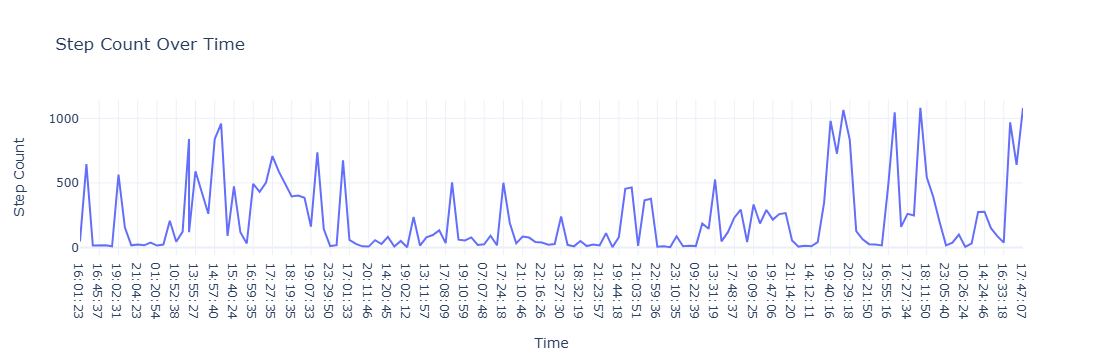

In [53]:
# Step Count Over Time
fig1 = px.line(data, x="Time",
               y="Step Count",
               title="Step Count Over Time")
fig1.show()

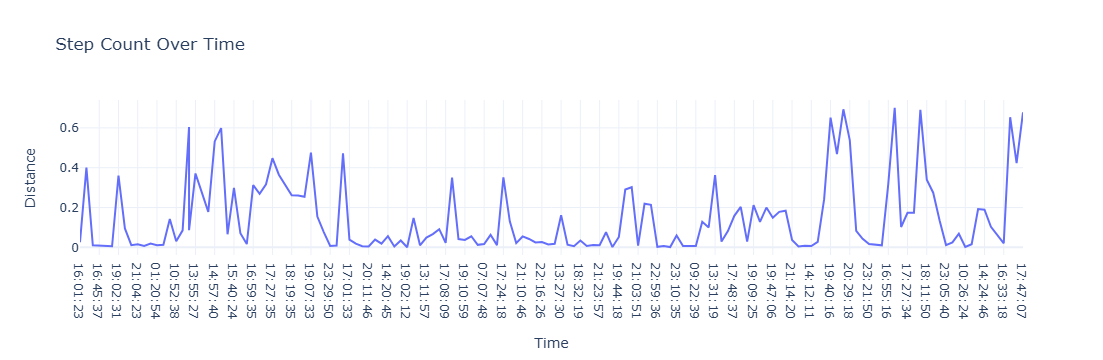

In [54]:
# Step Count Over Time
fig1 = px.line(data, x="Time",
               y="Distance",
               title="Step Count Over Time")
fig1.show()

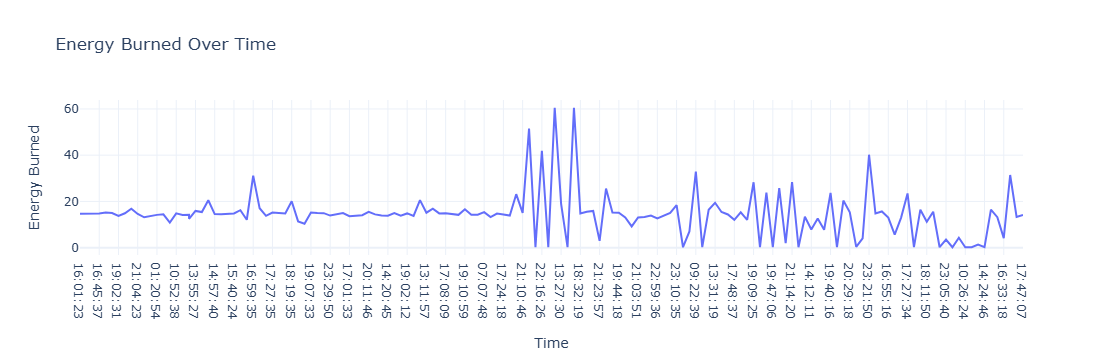

In [55]:
# Energy Burned Over Time
fig3 = px.line(data, x="Time",
               y="Energy Burned",
               title="Energy Burned Over Time")
fig3.show()

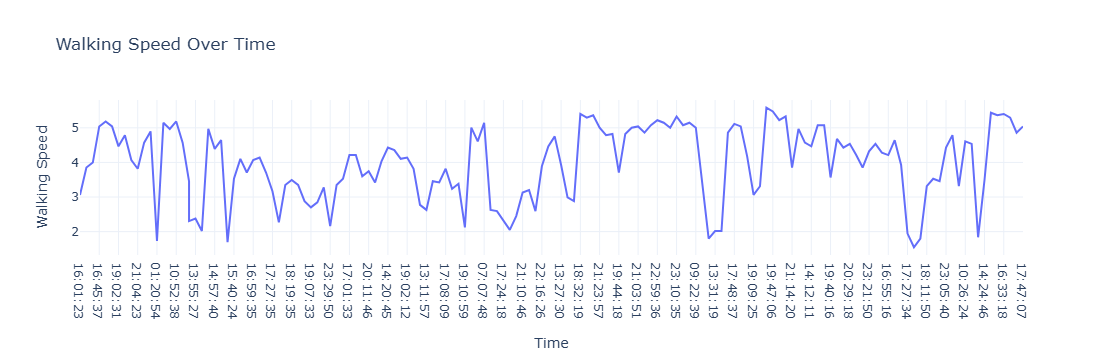

In [56]:
# Walking Speed Over Time
fig4 = px.line(data, x="Time",
               y="Walking Speed",
               title="Walking Speed Over Time")
fig4.show()

average step count per day

In [57]:
step_count_per_day = data.groupby('Date')['Step Count'].mean()
step_count_per_day

Date
2023-03-21    137.636364
2023-03-22    354.233333
2023-03-23    109.125000
2023-03-24     64.666667
2023-03-25    117.000000
2023-03-26    101.000000
2023-03-27     48.875000
2023-03-28    163.750000
2023-03-29    169.578947
2023-03-30    384.181818
2023-03-31    372.166667
2023-04-01    306.916667
Name: Step Count, dtype: float64

In [58]:
step_count_per_day = data.groupby('Date')['Step Count'].mean().reset_index()
step_count_per_day

,Date,Step Count
0,2023-03-21,137.636364
1,2023-03-22,354.233333
2,2023-03-23,109.125000
3,2023-03-24,64.666667
4,2023-03-25,117.000000
5,2023-03-26,101.000000
6,2023-03-27,48.875000
7,2023-03-28,163.750000
8,2023-03-29,169.578947
9,2023-03-30,384.181818


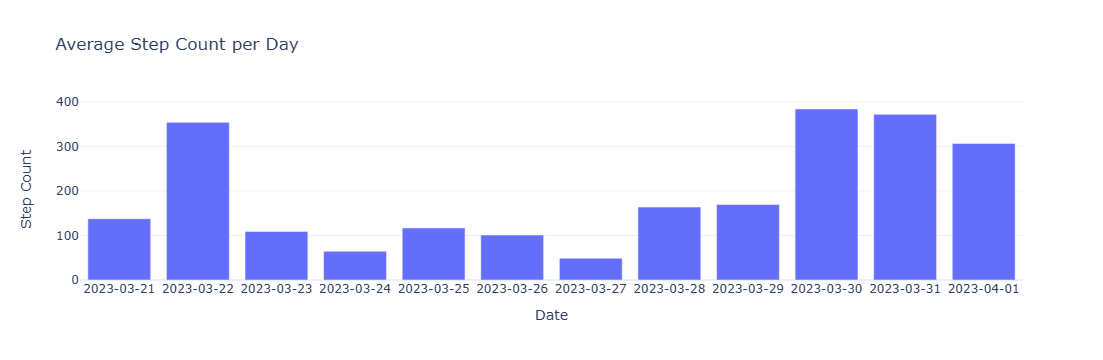

In [59]:
fig5 = px.bar(step_count_per_day, x = 'Date', y = 'Step Count', title="Average Step Count per Day")
fig5.update_xaxes(type='category')

fig5.show()

The method update_xaxes(type='category') in Plotly is used to update the x-axis of a figure to treat the x-axis data as categorical. This means that instead of treating the x-axis data as continuous or numeric, Plotly will treat each unique value as a distinct category.

In [60]:
data.columns

Index(['Date', 'Time', 'Step Count', 'Distance', 'Energy Burned',
       'Flights Climbed', 'Walking Double Support Percentage',
       'Walking Speed'],
      dtype='object')

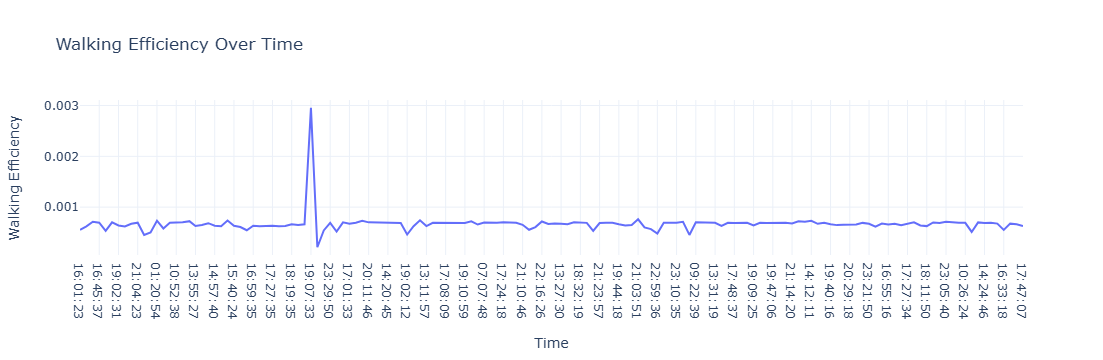

In [61]:
# Calculate Walking Efficiency
data["Walking Efficiency"] = data["Distance"] / data["Step Count"]

fig6 = px.line(data, x="Time",
               y="Walking Efficiency",
               title="Walking Efficiency Over Time")
fig6.show()

C:\Users\vaish\AppData\Local\Temp\ipykernel_34312\2894008012.py:2: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

C:\Users\vaish\anaconda3\Lib\site-packages\plotly\express\_core.py:1958: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



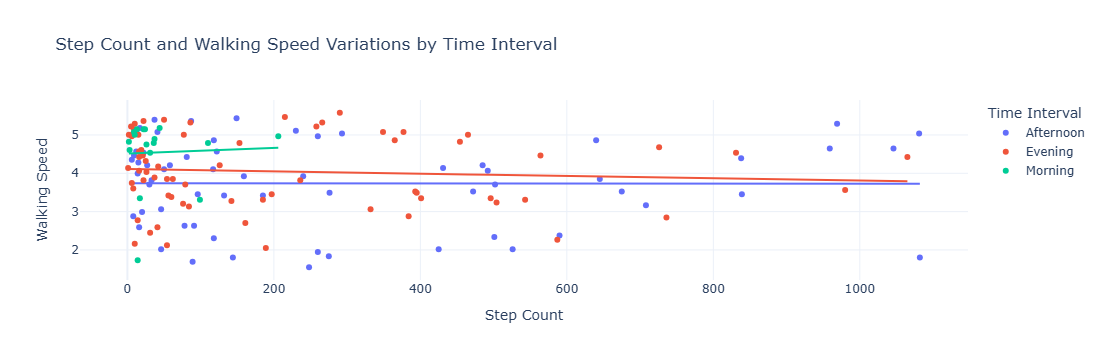

In [62]:
# Create Time Intervals
time_intervals = pd.cut(pd.to_datetime(data["Time"]).dt.hour,
                        bins=[0, 12, 18, 24],
                        labels=["Morning", "Afternoon", "Evening"], 
                        right=False)

data["Time Interval"] = time_intervals

# Variations in Step Count and Walking Speed by Time Interval
fig7 = px.scatter(data, x="Step Count",
                  y="Walking Speed",
                  color="Time Interval",
                  title="Step Count and Walking Speed Variations by Time Interval",
                  trendline='ols')
fig7.show()

Now, let’s compare the daily average of all the health and fitness metrics: